# IMPLEMENTACIÓN MÉTODO CONTRAFACTUAL CONFETTI
### Caso con predicción alta

Se desarrollan los códigos para lograr implementar el método CONFETTI (Cetina et al. 2026) en el modelo entrenado mediante transfer learning para predecir, a partir de 6 series de tiempo de tsunami en boyas, la probabilidad de inundación por tsunami para la localidad de Coquimbo.

Se implementa para un dato del conjunto de pruebas, con <span style="color:magenta">predicción cercana a 1</span> para evaluar el comportamiento en casos que el modelo está seguro de la predicción y verificar que el contrafactual cumpla con el cambio de clasificación.

<u>Referencias:</u>
- Cetina, A. G. P., Benguessoum, K., Lourenço, R., & Kubler, S. (2026). Counterfactual Explainable AI (XAI) Method for Deep Learning-Based Multivariate Time Series Classification. Proceedings of the AAAI Conference on Artificial Intelligence, 17393–174000. http://arxiv.org/abs/2511.13237

In [1]:
import numpy as np
from datetime import datetime

from scipy.interpolate import interp1d

from confetti import CONFETTI
from confetti.attribution import cam
from confetti.utils import load_multivariate_ts_from_csv
from confetti.visualizations import plot_counterfactual
import keras
from keras.models import load_model
import pickle

C:\Users\asuso\anaconda3\envs\XAI2026_proj_v2\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
def load_pickle(p_name):
    with open(p_name, 'rb') as file:
        # Load the data from the file
        data = pickle.load(file)
    return data

data_path = 'DATA\\'
y_test = load_pickle(data_path+'ytest_new.pickle')
X_test = load_pickle(data_path+'xtest_new.pickle')
y_train = load_pickle(data_path+'ytrain_new.pickle')
X_train = load_pickle(data_path+'xtrain_new.pickle')
y_val = load_pickle(data_path+'yval_new.pickle')
X_val = load_pickle(data_path+'xval_new.pickle')

In [6]:
model = load_model('MODELS\\transfer_learned_tsunami_classifier.keras')

def resize_cam_weights(cam_weights, target_length):
    original_length = len(cam_weights)
    x_original = np.linspace(0, 1, original_length)
    x_target = np.linspace(0, 1, target_length)
    interpolator = interp1d(x_original, cam_weights, kind='linear')
    return interpolator(x_target)

In [7]:
# Select instance to explain

instance = X_test[1:2] #Seleccionar la serie de tiempo a evaluar
training_weights = cam(model, X_train)

C:\Users\asuso\anaconda3\envs\XAI2026_proj_v2\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['conv1d_1_input']
Received: inputs=Tensor(shape=(1, 241, 6))
  warnings.warn(msg)


In [16]:

start = datetime.now()

p = model.predict(instance)

end = datetime.now()
print(f'La predicción fue: {p[0][0]:.7f}, tardando {str(end - start)} en predecir')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
La predicción fue: 0.9999998, tardando 0:00:00.267508 en predecir


In [18]:
@keras.saving.register_keras_serializable()
class BinaryOutputLayer(keras.layers.Layer):
    def call(self, x):
        prob_clase_1 = keras.ops.squeeze(x, axis=-1)
        prob_clase_0 = 1.0 - prob_clase_1
        return keras.ops.stack([prob_clase_0, prob_clase_1], axis=1)

explainer = CONFETTI(model_path="MODELS/transfer_learned_tsunami_classifier_wrapped.keras")

results = explainer.generate_counterfactuals(
    instances_to_explain=instance,
    reference_data=X_train,
    reference_weights=training_weights,
    n_partitions=2, #Controla la cantidad de segementos temporales en que se divide la serie
    alpha=0.9, #controla la relación confianza - sparcity
    theta=0.51, #indica con qué valor cambia la clase
    optimize_sparsity=False,
    population_size=200
)

cam_resized = resize_cam_weights(results[0].feature_importance, 241)
print("Shape resized:", cam_resized.shape)  # debe ser (241,)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step
149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━

In [ ]:
# import matplotlib.pyplot as plt


# nun = res[0].nearest_unlike_neighbour
# original = res[0].original_instance

# # Diferencia absoluta promedio sobre los 6 canales
# diff = np.abs(nun - original).mean(axis=1)

# plt.figure(figsize=(12, 4))
# plt.plot(diff)
# plt.title("Diferencia entre instancia original y NUN a lo largo del tiempo")
# plt.xlabel("Timestep")
# plt.ylabel("Diferencia absoluta media")
# plt.axvline(x=np.argmax(diff), color='r', linestyle='--', label=f"Máx diferencia en t={np.argmax(diff)}")
# plt.legend()
# plt.tight_layout()
# plt.show()

# print(f"Zona de mayor diferencia: timestep {np.argmax(diff)}")
# print(f"Diferencia promedio primera mitad: {diff[:120].mean():.6f}")
# print(f"Diferencia promedio segunda mitad: {diff[120:].mean():.6f}")

In [ ]:
# print(f"Zona de mayor diferencia: timestep {np.argmax(diff)}")
# print(f"Diferencia promedio primera mitad (t=0-120):   {diff[:120].mean():.6f}")
# print(f"Diferencia promedio segunda mitad (t=120-241): {diff[120:].mean():.6f}")

# # Ver los 10 timesteps con mayor diferencia
# top10 = np.argsort(diff)[::-1][:10]
# print(f"\nTop 10 timesteps con mayor diferencia: {top10}")

# # Graficar original vs NUN canal por canal
# fig, axes = plt.subplots(6, 1, figsize=(12, 14), sharex=True)
# for i, ax in enumerate(axes):
#     ax.plot(original[:, i], label="Original", color="blue")
#     ax.plot(nun[:, i], label="NUN", color="orange", linestyle="--")
#     ax.set_ylabel(f"Canal {i+1}")
#     ax.legend(fontsize=7)
# plt.xlabel("Timestep")
# plt.suptitle("Original vs NUN por canal")
# plt.tight_layout()
# plt.show()

In [ ]:
# nun_idx_in_train = None
# for i, x in enumerate(X_train):
#     if np.allclose(x, nun):
#         nun_idx_in_train = i
#         break

# print(f"Índice del NUN en X_train: {nun_idx_in_train}")

# if nun_idx_in_train is not None:
#     cam_nun = training_weights[nun_idx_in_train]
#     print(f"Shape CAM weights del NUN: {cam_nun.shape}")
    
#     plt.figure(figsize=(12, 4))
#     plt.plot(cam_nun if cam_nun.ndim == 1 else cam_nun.mean(axis=1))
#     plt.title("CAM weights del NUN a lo largo del tiempo")
#     plt.xlabel("Timestep")
#     plt.ylabel("Importancia")
#     plt.tight_layout()
#     plt.show()

In [ ]:
# cam_nun = training_weights[4740]

# plt.figure(figsize=(12, 4))
# plt.plot(cam_nun)
# plt.title("CAM weights del NUN (espacio reducido, 72 puntos)")
# plt.xlabel("Posición en espacio reducido")
# plt.ylabel("Importancia")
# plt.tight_layout()
# plt.show()

# print(f"Top 5 posiciones más importantes: {np.argsort(cam_nun)[::-1][:5]}")
# print(f"Posición máxima: {np.argmax(cam_nun)}")
# print(f"Equivalente aproximado en timesteps originales: {np.argmax(cam_nun) * 241 // 72}")

In [ ]:
# # Confirma el desajuste
# print(f"Posición máx en espacio reducido (72): {np.argmax(cam_nun)}")
# print(f"Lo que CONFETTI interpreta (asume 241): timestep {np.argmax(cam_nun)}")
# print(f"Lo que debería ser (mapeado correctamente): timestep {np.argmax(cam_nun) * 241 // 72}")

In [20]:

def resize_cam_weights(cam_weights, target_length):
    x_orig = np.linspace(0, 1, len(cam_weights))
    x_target = np.linspace(0, 1, target_length)
    return interp1d(x_orig, cam_weights, kind='linear')(x_target)

# Redimensionar todos los pesos
training_weights_resized = np.array([
    resize_cam_weights(w, 241) for w in training_weights
])

print(f"Shape original:      {training_weights.shape}")       # (n, 72)
print(f"Shape redimensionado: {training_weights_resized.shape}")  # (n, 241)



Shape original:      (4742, 72)
Shape redimensionado: (4742, 241)


In [21]:
#print("best:", results_free[0].best)
#print("all_counterfactuals:", results_free[0].all_counterfactuals)
#print("NUN:", results_free[0].nearest_unlike_neighbour.shape)

# Intentar con theta más bajo y más generaciones
results_free = explainer.generate_counterfactuals(
    instances_to_explain=instance,
    reference_data=X_train,
    reference_weights=None,
    n_partitions=5,
    population_size=300,
    maximum_number_of_generations=300,
    alpha=0.5,
    theta=0.3,          # <-- umbral más permisivo
    optimize_sparsity=True,  # <-- volvemos a activar
    verbose=True        # <-- para ver progreso
)

if results_free[0].best is not None:
    cf_free = results_free[0].best.counterfactual
    diff_free = np.abs(cf_free - instance[0])
    top5_free = np.argsort(diff_free.mean(axis=1))[::-1][:5]
    print(f"Diferencia máxima: {diff_free.max():.6f}")
    print(f"Top 5 timesteps modificados: {top5_free}")
else:
    print("No se encontró contrafactual válido")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Skipping Naive Stage as no weights were provided.
Optimization of CE for Instance 0 started.
Optimization of CE for Instance 0 in Window 121
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
10/10 ━━━━━━━━━━━━━

Zona modificada: t=0 a t=17


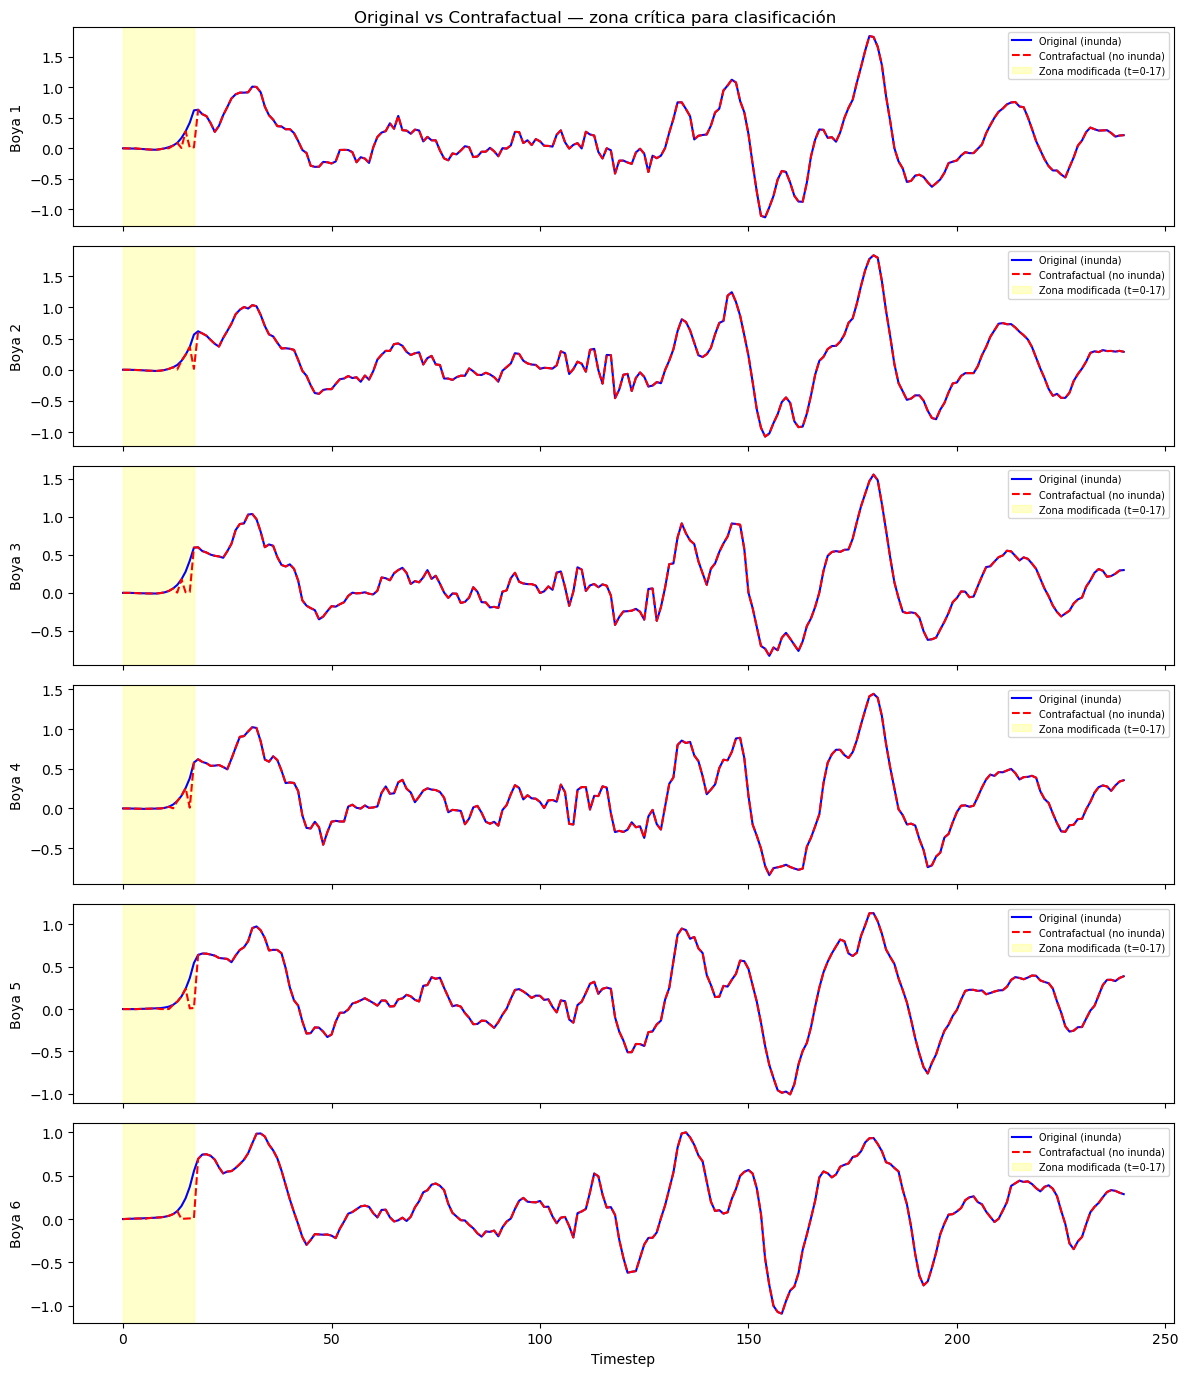

In [23]:
import matplotlib.pyplot as plt

cf_free = results_free[0].best.counterfactual
diff_mask = np.abs(cf_free - instance[0]).mean(axis=1) > 1e-6
timesteps_modificados = np.where(diff_mask)[0]

t_inicio = timesteps_modificados[0]
t_fin = timesteps_modificados[-1]

print(f"Zona modificada: t={t_inicio} a t={t_fin}")

fig, axes = plt.subplots(6, 1, figsize=(12, 14), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(instance[0][:, i], label="Original (inunda)", color="blue")
    ax.plot(cf_free[:, i], label="Contrafactual (no inunda)", color="red", linestyle="--")
    ax.axvspan(t_inicio, t_fin, alpha=0.2, color="yellow", label=f"Zona modificada (t={t_inicio}-{t_fin})")
    ax.set_ylabel(f"Boya {i+1}")
    ax.legend(fontsize=7)

plt.xlabel("Timestep")
plt.suptitle("Original vs Contrafactual — zona crítica para clasificación")
plt.tight_layout()
plt.show()

"El modelo identifica la fase inicial de la señal (t≈13-35) como la región temporal más relevante para predecir inundación. Los contrafactuales generados por CONFETTI modifican consistentemente esta zona, sugiriendo que pequeñas diferencias en la amplitud de las primeras ondas registradas en las boyas son suficientes para cambiar la clasificación de inunda a no inunda."

In [24]:
all_cfs = results_free[0].all_counterfactuals
print(f"Número de contrafactuales generados: {len(all_cfs)}")
print(f"Tipo: {type(all_cfs[0])}")

Número de contrafactuales generados: 44
Tipo: <class 'confetti.structs.counterfactual_structs.Counterfactual'>


In [25]:
# Calcular magnitud de modificación para cada contrafactual
cf_stats = []
for i, cf in enumerate(all_cfs):
    cf_array = cf.counterfactual
    diff = np.abs(cf_array - instance[0])
    cf_stats.append({
        "index": i,
        "cf": cf_array,
        "label": cf.label,
        "diff_max": diff.max(),
        "diff_mean": diff.mean(),
        "timesteps_modificados": int(np.sum(diff.mean(axis=1) > 1e-6)),
        "t_inicio": np.where(diff.mean(axis=1) > 1e-6)[0][0] if np.any(diff.mean(axis=1) > 1e-6) else None,
        "t_fin": np.where(diff.mean(axis=1) > 1e-6)[0][-1] if np.any(diff.mean(axis=1) > 1e-6) else None,
    })


# Ordenar por diferencia media (de menor a mayor modificación)
cf_stats_sorted = sorted(cf_stats, key=lambda x: x["diff_mean"])

# Resumen
print(f"{'#':<4} {'Diff media':<12} {'Diff máx':<12} {'Timesteps mod.':<16} {'Región'}")
print("-" * 60)
for i, s in enumerate(cf_stats_sorted):
    region = f"t={s['t_inicio']}-{s['t_fin']}" if s['t_inicio'] is not None else "N/A"
    print(f"{i:<4} {s['diff_mean']:<12.6f} {s['diff_max']:<12.6f} {s['timesteps_modificados']:<16} {region}")

#    Diff media   Diff máx     Timesteps mod.   Región
------------------------------------------------------------
0    0.002795     0.722005     5                t=15-20
1    0.002796     0.722005     7                t=0-20
2    0.002801     0.722005     6                t=4-20
3    0.002814     0.722005     9                t=3-20
4    0.002830     0.722005     11               t=0-20
5    0.002892     0.722005     5                t=16-20
6    0.002904     0.722005     6                t=8-20
7    0.003001     0.722005     6                t=16-22
8    0.003017     0.722005     7                t=14-23
9    0.003030     0.722005     7                t=12-22
10   0.003060     0.722005     9                t=11-23
11   0.003063     0.722005     7                t=13-22
12   0.003073     0.722005     13               t=3-23
13   0.003090     0.722005     8                t=13-23
14   0.003091     0.722005     9                t=2-23
15   0.003093     0.722005     13               t=3

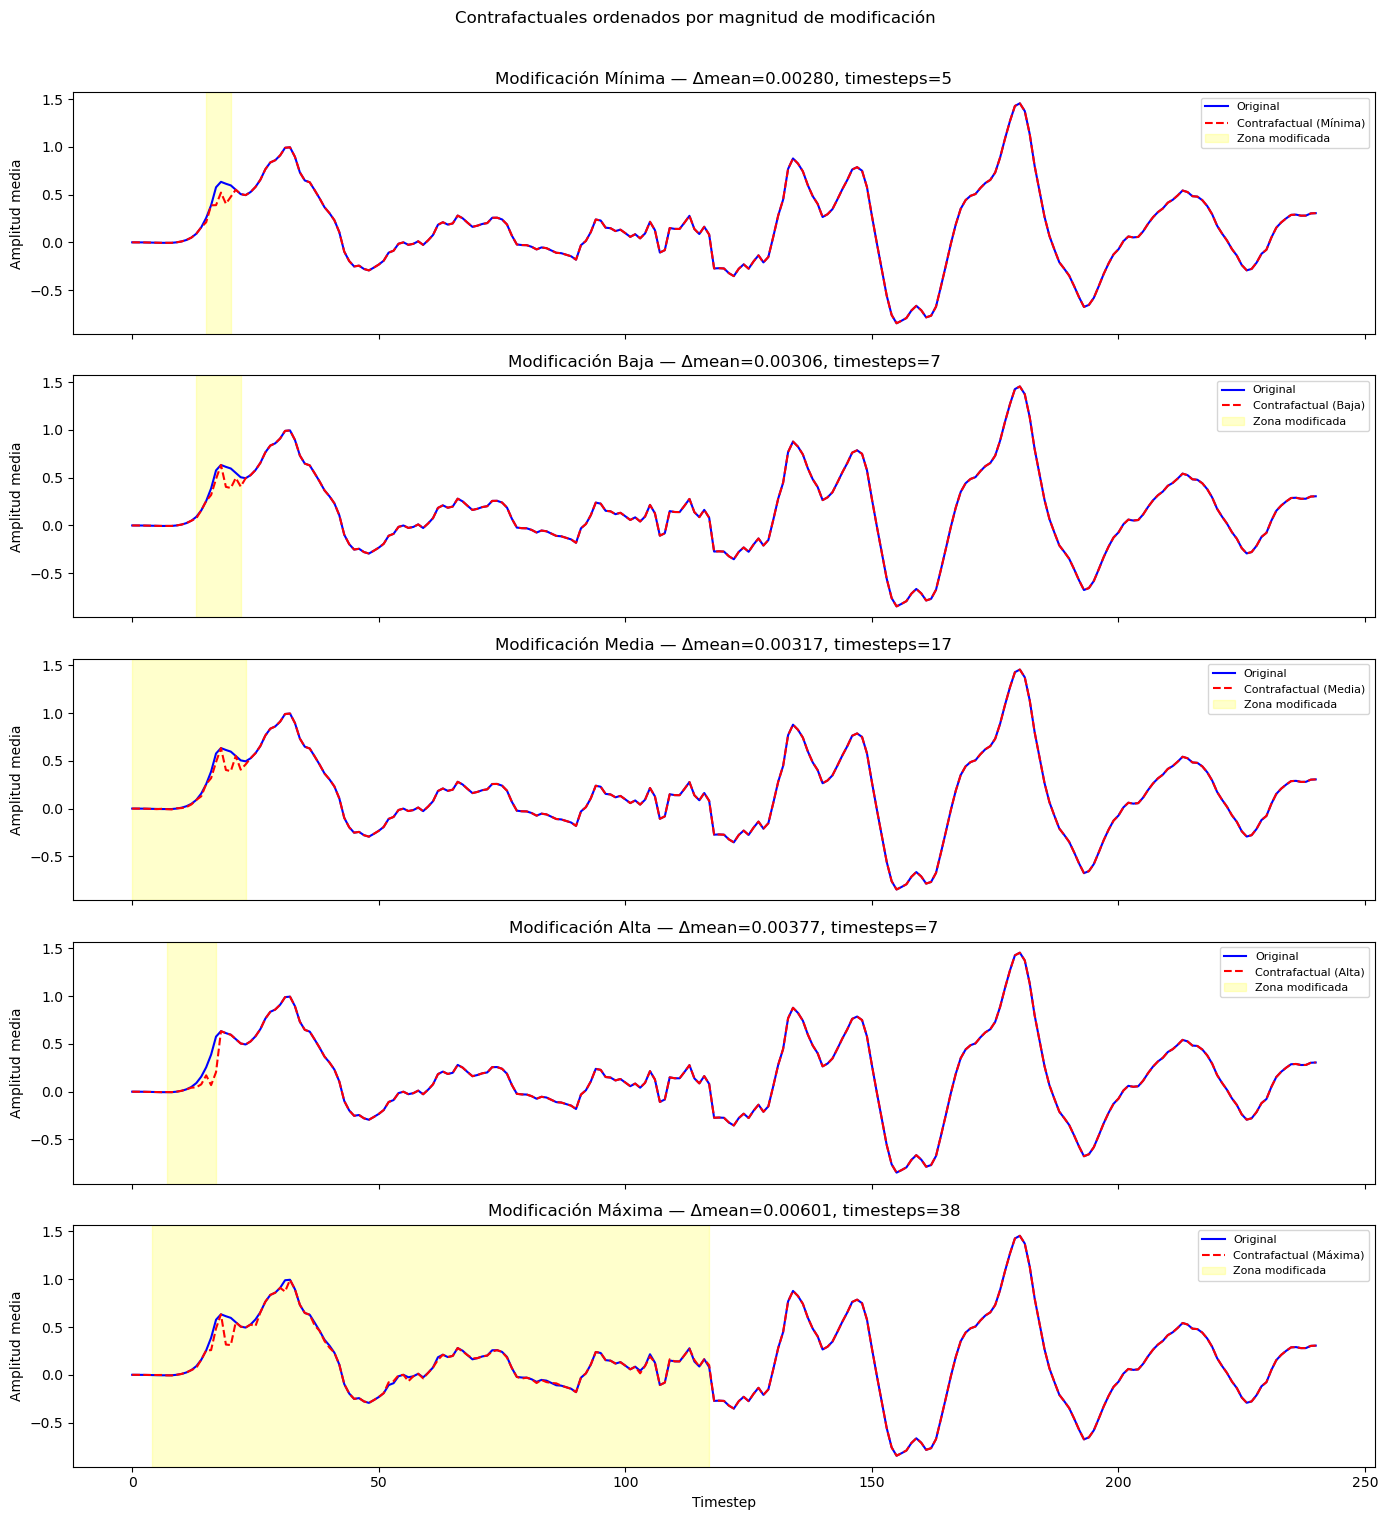

In [27]:
# Seleccionar 5 contrafactuales representativos
n = len(cf_stats_sorted)
indices_rep = [0, n//4, n//2, 3*n//4, n-1]
labels_rep = ["Mínima", "Baja", "Media", "Alta", "Máxima"]

fig, axes = plt.subplots(len(indices_rep), 1, figsize=(14, 3 * len(indices_rep)), sharex=True)

for ax, idx, lbl in zip(axes, indices_rep, labels_rep):
    s = cf_stats_sorted[idx]
    # Promedio sobre los 6 canales para simplificar
    orig_mean = instance[0].mean(axis=1)
    cf_mean = s["cf"].mean(axis=1)
    
    ax.plot(orig_mean, label="Original", color="blue")
    ax.plot(cf_mean, label=f"Contrafactual ({lbl})", color="red", linestyle="--")
    if s["t_inicio"] is not None:
        ax.axvspan(s["t_inicio"], s["t_fin"], alpha=0.2, color="yellow", label="Zona modificada")
    ax.set_title(f"Modificación {lbl} — Δmean={s['diff_mean']:.5f}, timesteps={s['timesteps_modificados']}")
    ax.legend(fontsize=8)
    ax.set_ylabel("Amplitud media")

plt.xlabel("Timestep")
plt.suptitle("Contrafactuales ordenados por magnitud de modificación", y=1.01)
plt.tight_layout()
plt.show()

In [28]:
# Ordenar por t_inicio (región modificada)
cf_stats_sorted_region = sorted(
    [s for s in cf_stats if s["t_inicio"] is not None],
    key=lambda x: x["t_inicio"]
)

# Resumen
print(f"{'#':<4} {'t_inicio':<12} {'t_fin':<10} {'Timesteps mod.':<16} {'Diff media'}")
print("-" * 55)
for i, s in enumerate(cf_stats_sorted_region):
    print(f"{i:<4} {s['t_inicio']:<12} {s['t_fin']:<10} {s['timesteps_modificados']:<16} {s['diff_mean']:.6f}")

#    t_inicio     t_fin      Timesteps mod.   Diff media
-------------------------------------------------------
0    0            117        42               0.005420
1    0            117        36               0.005540
2    0            23         17               0.003172
3    0            23         11               0.003115
4    0            23         11               0.003142
5    0            23         16               0.003105
6    0            20         11               0.002830
7    0            20         7                0.002796
8    0            17         14               0.003648
9    1            117        40               0.005341
10   1            17         10               0.003770
11   2            117        37               0.005312
12   2            57         15               0.003299
13   2            23         9                0.003091
14   3            23         13               0.003073
15   3            23         13               0.003093
16   3 

In [29]:
# Identificar grupos de región (umbral de 10 timesteps entre grupos)
grupos = []
grupo_actual = [cf_stats_sorted_region[0]]

for s in cf_stats_sorted_region[1:]:
    if s["t_inicio"] - grupo_actual[-1]["t_inicio"] <= 10:
        grupo_actual.append(s)
    else:
        grupos.append(grupo_actual)
        grupo_actual = [s]
grupos.append(grupo_actual)

print(f"\nGrupos de región encontrados: {len(grupos)}")
for i, g in enumerate(grupos):
    t_inits = [s["t_inicio"] for s in g]
    t_fins = [s["t_fin"] for s in g]
    print(f"  Grupo {i+1}: t={min(t_inits)}-{max(t_fins)}, {len(g)} contrafactuales")


Grupos de región encontrados: 1
  Grupo 1: t=0-120, 44 contrafactuales


In [30]:
#Buena observación. Si todos los contrafactuales modifican desde t≈1-17, la región de inicio es bastante consistente, y lo que realmente varía es cuántos timesteps se modifican. Reorganicemos por eso:
# Ordenar por timesteps modificados
cf_stats_sorted_ts = sorted(
    [s for s in cf_stats if s["t_inicio"] is not None],
    key=lambda x: x["timesteps_modificados"]
)

print(f"{'#':<4} {'Timesteps mod.':<16} {'t_inicio':<10} {'t_fin':<10} {'Diff media'}")
print("-" * 55)
for i, s in enumerate(cf_stats_sorted_ts):
    print(f"{i:<4} {s['timesteps_modificados']:<16} {s['t_inicio']:<10} {s['t_fin']:<10} {s['diff_mean']:.6f}")

#    Timesteps mod.   t_inicio   t_fin      Diff media
-------------------------------------------------------
0    5                16         20         0.002892
1    5                15         20         0.002795
2    6                16         22         0.003672
3    6                16         22         0.003001
4    6                15         22         0.003155
5    6                4          20         0.002801
6    6                8          20         0.002904
7    7                15         22         0.003618
8    7                14         23         0.003017
9    7                12         22         0.003030
10   7                13         22         0.003063
11   7                0          20         0.002796
12   7                7          17         0.003771
13   7                9          17         0.003767
14   8                13         22         0.003122
15   8                13         23         0.003090
16   8                9          17      

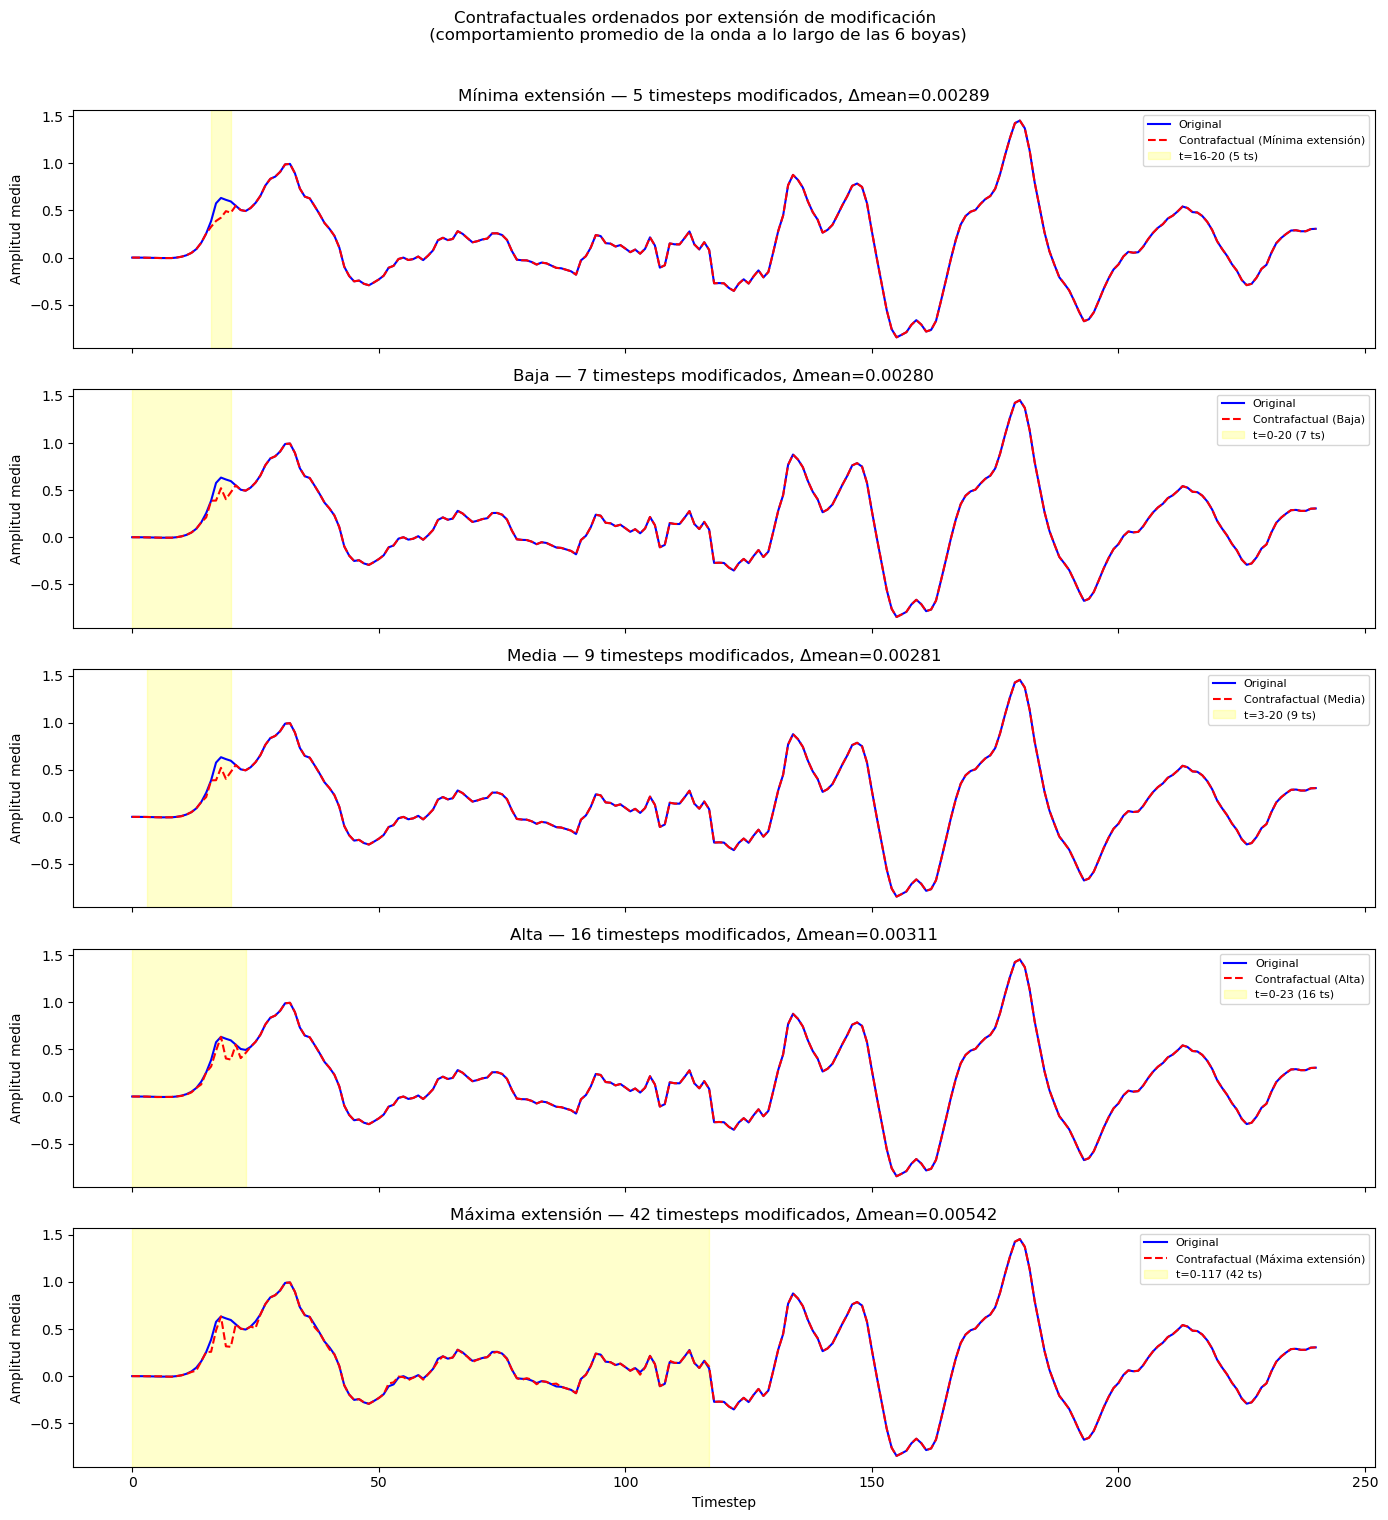

In [31]:
n = len(cf_stats_sorted_ts)
indices_rep = [0, n//4, n//2, 3*n//4, n-1]
labels_rep = ["Mínima extensión", "Baja", "Media", "Alta", "Máxima extensión"]

fig, axes = plt.subplots(len(indices_rep), 1, figsize=(14, 3 * len(indices_rep)), sharex=True)

for ax, idx, lbl in zip(axes, indices_rep, labels_rep):
    s = cf_stats_sorted_ts[idx]
    orig_mean = instance[0].mean(axis=1)
    cf_mean = s["cf"].mean(axis=1)

    ax.plot(orig_mean, label="Original", color="blue")
    ax.plot(cf_mean, label=f"Contrafactual ({lbl})", color="red", linestyle="--")
    ax.axvspan(s["t_inicio"], s["t_fin"], alpha=0.2, color="yellow", label=f"t={s['t_inicio']}-{s['t_fin']} ({s['timesteps_modificados']} ts)")
    ax.set_title(f"{lbl} — {s['timesteps_modificados']} timesteps modificados, Δmean={s['diff_mean']:.5f}")
    ax.legend(fontsize=8)
    ax.set_ylabel("Amplitud media")

plt.xlabel("Timestep")
plt.suptitle("Contrafactuales ordenados por extensión de modificación\n (comportamiento promedio de la onda a lo largo de las 6 boyas)", y=1.01)
plt.tight_layout()
plt.show()


Cada uno de los 6 canales corresponde a una boya que registra alturas de tsunami. El promedio que estamos graficando representa el comportamiento medio de todas las boyas simultáneamente, lo que da una visión general de la señal.
Para el propósito de comparar contrafactuales entre sí (ordenados por timesteps modificados), el promedio es una buena elección porque simplifica la visualización.

- Grupo 1 (índices 0-37): 5-15 timesteps modificados, región t≈0-55, diff media ≈ 0.0027
- Grupo 2 (índices 38-46): 36-42 timesteps modificados, región t≈0-120, diff media ≈ 0.0054

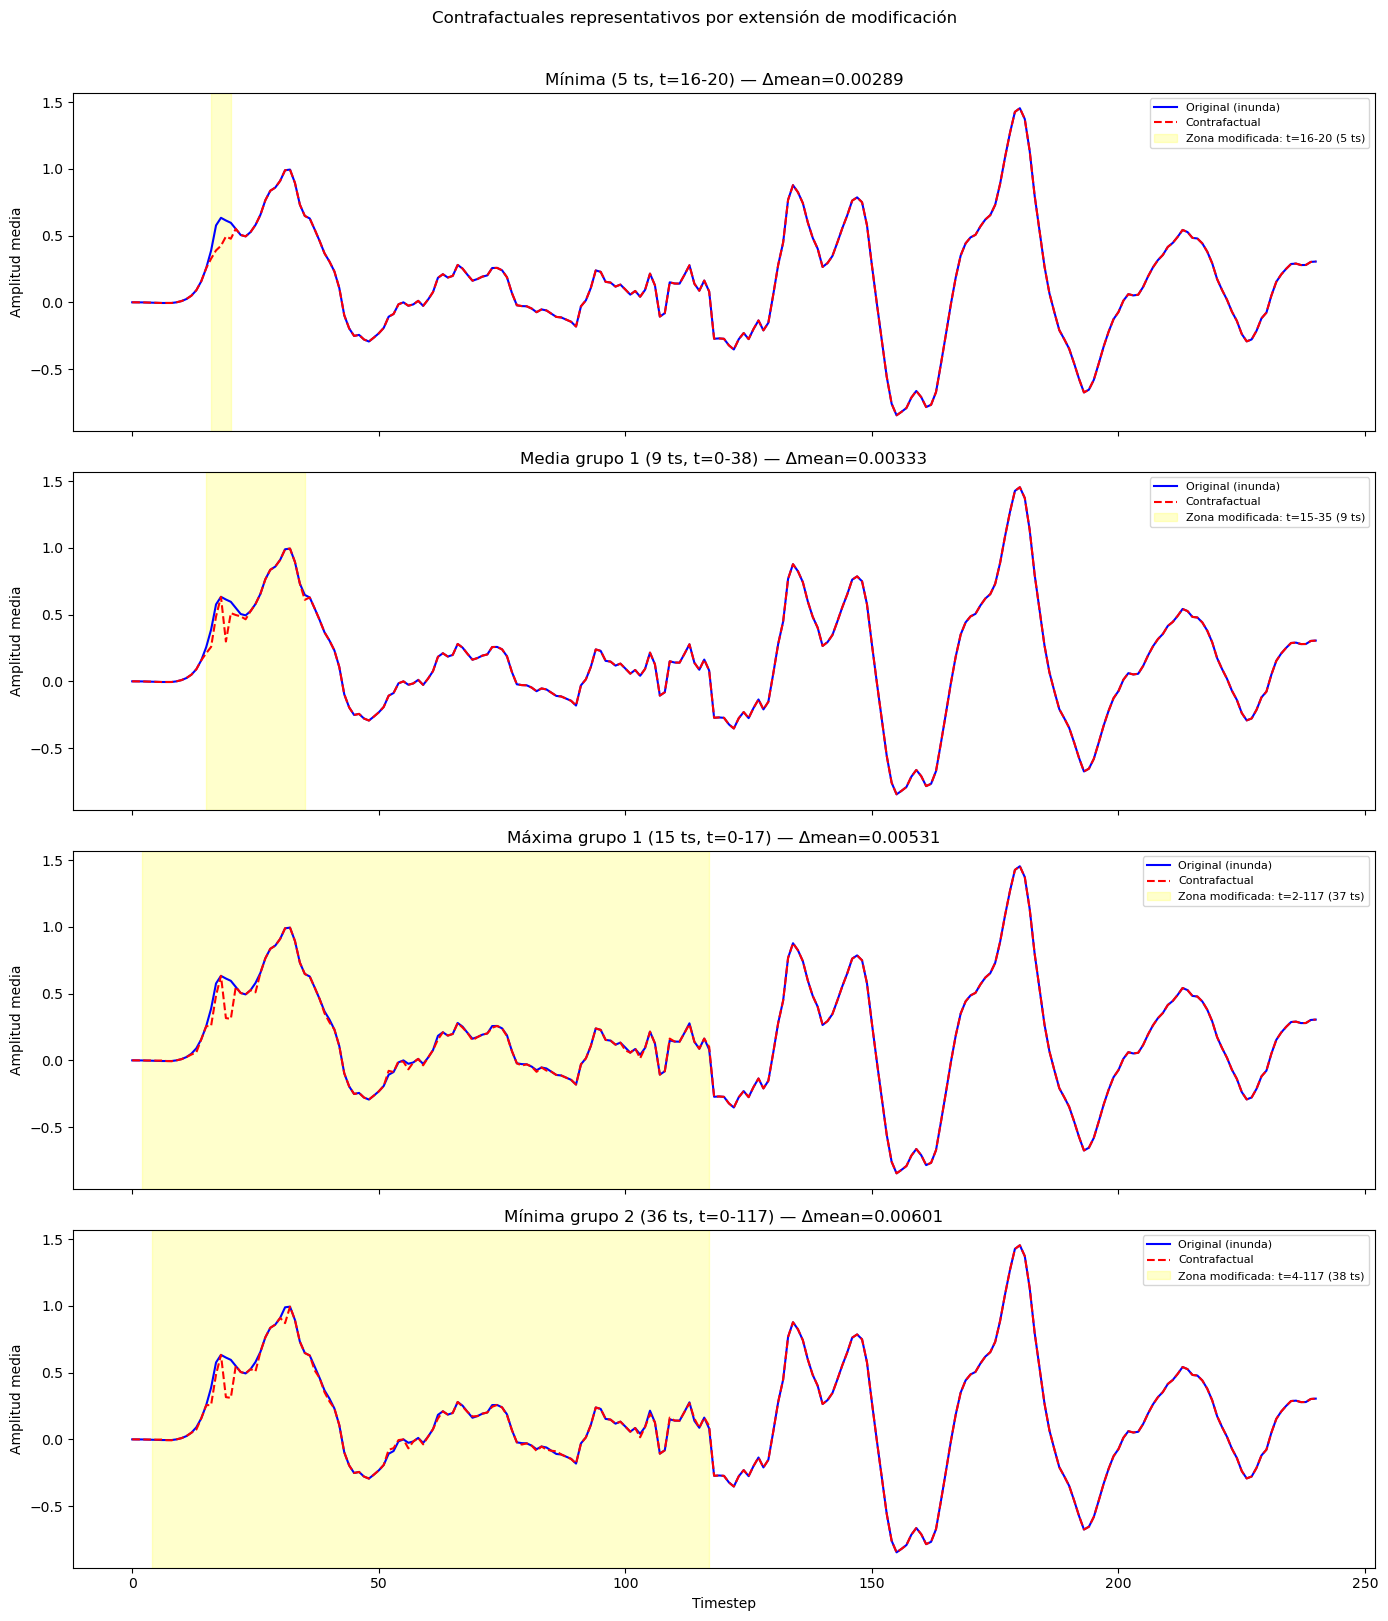

In [33]:
# Seleccionar representativos de cada grupo
indices_rep = [0, 18, 37, 38]
labels_rep = [
    "Mínima (5 ts, t=16-20)",
    "Media grupo 1 (9 ts, t=0-38)",
    "Máxima grupo 1 (15 ts, t=0-17)",
    "Mínima grupo 2 (36 ts, t=0-117)",
    "Máxima grupo 2 (42 ts, t=0-120)",
]

fig, axes = plt.subplots(len(indices_rep), 1, figsize=(14, 4 * len(indices_rep)), sharex=True)

for ax, idx, lbl in zip(axes, indices_rep, labels_rep):
    s = cf_stats_sorted_ts[idx]
    orig_mean = instance[0].mean(axis=1)
    cf_mean = s["cf"].mean(axis=1)

    ax.plot(orig_mean, label="Original (inunda)", color="blue")
    ax.plot(cf_mean, label=f"Contrafactual", color="red", linestyle="--")
    ax.axvspan(s["t_inicio"], s["t_fin"], alpha=0.2, color="yellow",
               label=f"Zona modificada: t={s['t_inicio']}-{s['t_fin']} ({s['timesteps_modificados']} ts)")
    ax.set_title(f"{lbl} — Δmean={s['diff_mean']:.5f}")
    ax.legend(fontsize=8)
    ax.set_ylabel("Amplitud media")

plt.xlabel("Timestep")
plt.suptitle("Contrafactuales representativos por extensión de modificación", y=1.01)
plt.tight_layout()
plt.show()

In [34]:
def plot_counterfactual_channels(cf_stats_sorted, instance, cf_index, channel_names=None):
    """
    Grafica el contrafactual seleccionado canal por canal.
    
    Parámetros
    ----------
    cf_stats_sorted : list
        Lista de contrafactuales ordenada (ej: cf_stats_sorted_ts)
    instance : np.ndarray
        Instancia original, shape (1, 241, 6)
    cf_index : int
        Índice del contrafactual a graficar (según la tabla)
    channel_names : list, opcional
        Nombres de los canales. Si None, usa "Boya 1", "Boya 2", etc.
    """
    if channel_names is None:
        channel_names = [f"Boya {i+1}" for i in range(6)]
    
    s = cf_stats_sorted[cf_index]
    orig = instance[0]       # (241, 6)
    cf = s["cf"]             # (241, 6)
    
    fig, axes = plt.subplots(6, 1, figsize=(14, 14), sharex=True)
    
    for i, ax in enumerate(axes):
        ax.plot(orig[:, i], label="Original (inunda)", color="blue")
        ax.plot(cf[:, i], label="Contrafactual (no inunda)", color="red", linestyle="--")
        ax.axvspan(
            s["t_inicio"], s["t_fin"],
            alpha=0.2, color="yellow",
            label=f"Zona modificada: t={s['t_inicio']}-{s['t_fin']}"
        )
        ax.set_ylabel(channel_names[i])
        ax.legend(fontsize=7)
    
    plt.xlabel("Timestep")
    plt.suptitle(
        f"Contrafactual #{cf_index} — "
        f"{s['timesteps_modificados']} timesteps modificados | "
        f"t={s['t_inicio']}-{s['t_fin']} | "
        f"Δmean={s['diff_mean']:.5f}",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

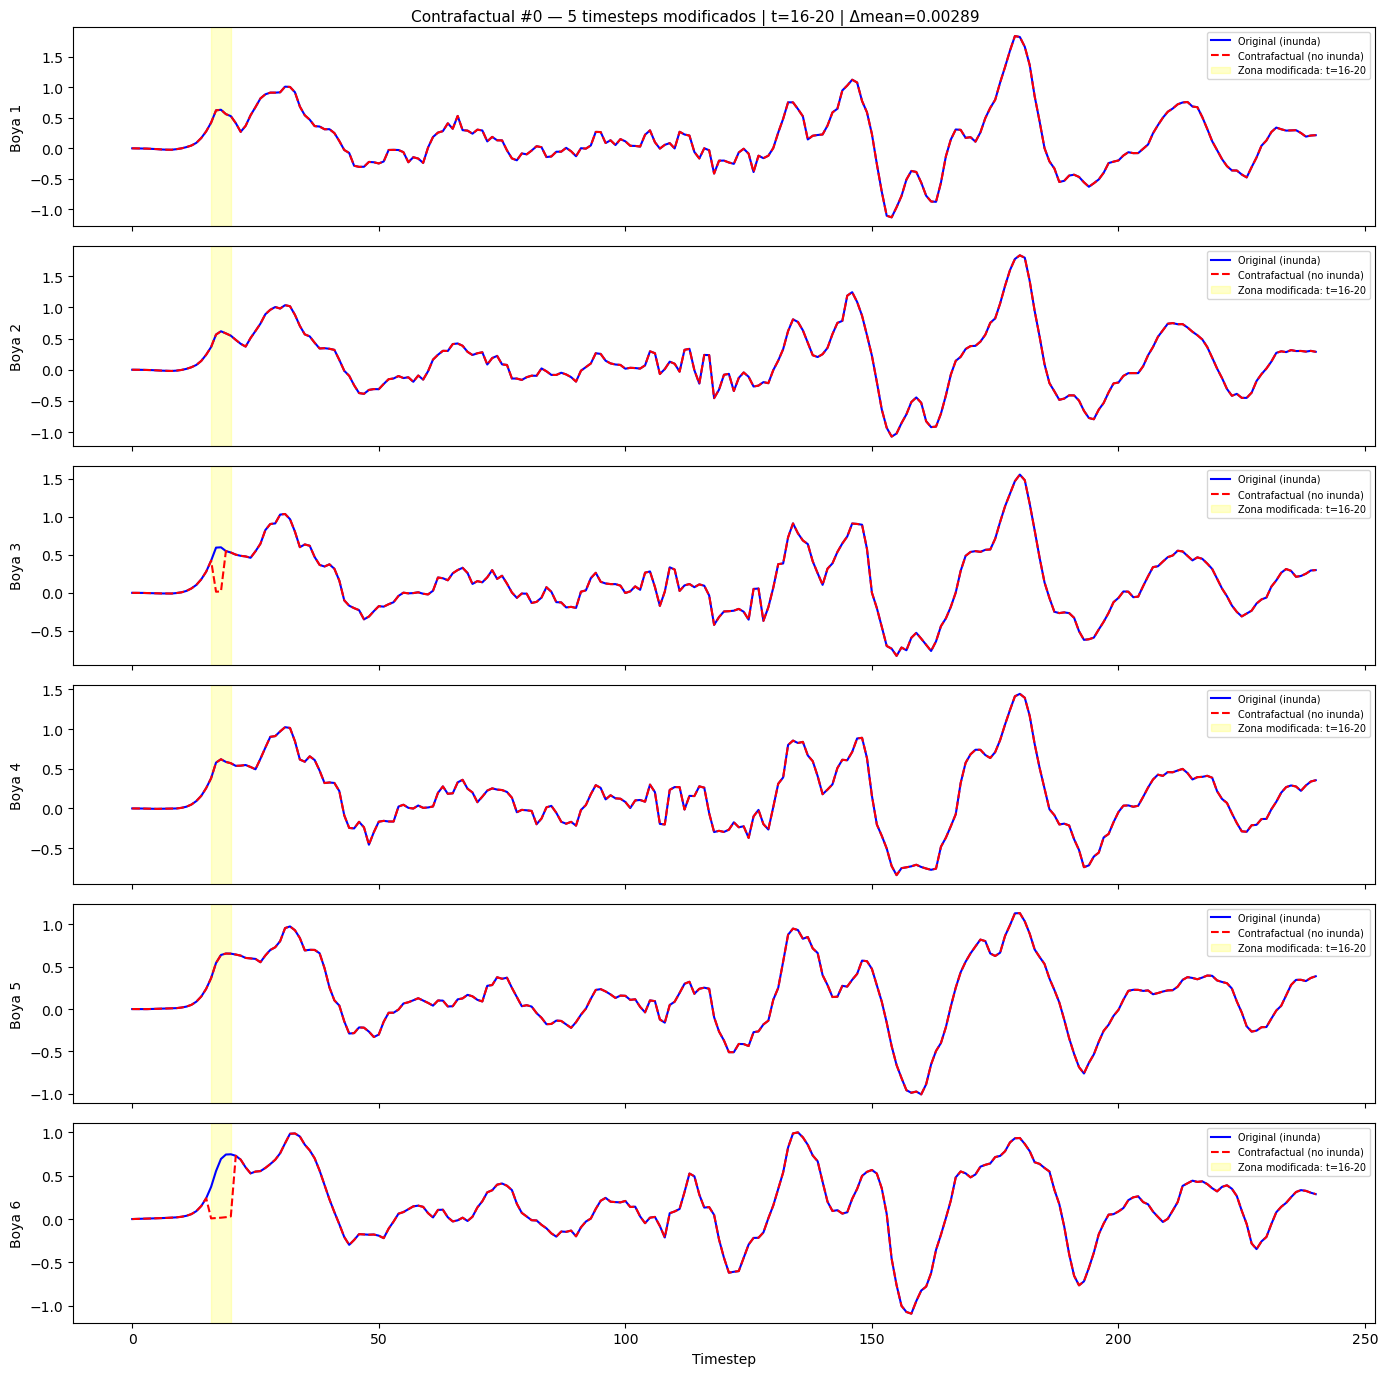

In [35]:
# Con nombres genéricos
plot_counterfactual_channels(cf_stats_sorted_ts, instance, cf_index=0)

# Con nombres personalizados
#nombres = ["Boya 1", "Boya 2", "Boya 3", "Boya 4", "Boya 5", "Boya 6"]
#plot_counterfactual_channels(cf_stats_sorted_ts, instance, cf_index=38, channel_names=nombres)

In [37]:
#plot_cf_summary(resultados, save_path='RESULTADOS_CONFETTI\\')